# CIA 3: Mission Earth — India AQI Prediction
**Predicting Air Quality Index (AQI) Levels for Public Health Early Warning Systems**

*MCA 521-4 Machine Learning | ML for Social Good Ensemble Challenge*

---

## Q1: Real-World Impact Framing

### Problem Statement
India's air quality crisis is a severe environmental health risk, contributing to millions of premature deaths
annually. Cities like Delhi, Patna, and Lucknow frequently breach "Severe" AQI levels (>400), triggering
respiratory emergencies. Municipal authorities need reliable AQI classification to activate the Graded
Response Action Plan (GRAP) proactively — odd-even traffic rules, construction bans, school closures.

### Beneficiaries
- **Municipal Authorities:** can activate GRAP stages before the spike rather than after it.
- **Hospitals:** pre-position nebulizers and oxygen supplies ahead of admission surges.
- **Vulnerable citizens:** asthmatics, the elderly, and children receive timely advisories.

### Prediction Target
- **Target variable:** `AQI_Bucket` — a 6-class ordinal classification (Good, Satisfactory, Moderate, Poor,
  Very Poor, Severe).
- **Unit of analysis:** one city-day observation (daily average pollutant readings for a given city).

### Measurable Impact
If the model flags a "Very Poor" or "Severe" day even a few hours ahead of the official bulletin, that is
enough lead time for a school to cancel outdoor assembly or a hospital to staff an extra respiratory bay.
We therefore treat **recall on the two worst classes** as the metric that actually matters, not raw accuracy.

### Dataset Source
Air Quality Data in India (2015–2020), compiled from the Central Pollution Control Board (CPCB) national
portal and published on Kaggle by Vopani (Rohan Rao) —
<https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india> (file: `city_day.csv`).
The data contains no personally identifiable information; every row is a station-level daily aggregate.

### Why Machine Learning?
AQI emerges from non-linear interactions between multiple pollutants (PM2.5, NO2, O3) and seasonal
meteorology such as winter temperature inversions. The official AQI formula is a max-of-sub-indices rule,
which means a threshold system needs complete readings for every pollutant to work at all. Sensors fail
constantly in the real world, and ensemble trees degrade gracefully with partial information where a
formula simply returns nothing.

### Responsible-Use Limitations
- Sensor coverage is heavily urban; rural India is essentially unrepresented.
- The model must *augment* human decision-making, not replace meteorological expertise.
- Trained on 2015–2020 data; post-pandemic industrial patterns may have shifted the relationships.

---
## Q2: Data Wrangling, EDA & Feature Engineering

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output folders for the submission bundle
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Consistent plot styling across the whole notebook
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 10,
})

# Fixed colours per AQI bucket, reused in every plot so the reader learns them once.
BUCKET_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
BUCKET_COLORS = ['#2ca25f', '#a1d99b', '#fed976', '#fd8d3c', '#e6550d', '#a50f15']
BUCKET_CMAP = dict(zip(BUCKET_ORDER, BUCKET_COLORS))

try:
    df = pd.read_csv('city_day.csv', parse_dates=['Date'])
except FileNotFoundError:
    df = pd.read_csv('../city_day.csv', parse_dates=['Date'])

print(f"Initial shape: {df.shape}")
print(f"Date range   : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Cities       : {df['City'].nunique()}")
df.head()

Initial shape: (29531, 16)
Date range   : 2015-01-01 to 2020-07-01
Cities       : 26


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


### 2.1 Data Audit — types, duplicates, missingness, invalid values

Before touching a single model we need to know what is actually wrong with this data. The audit below
checks the four things that most often silently corrupt a pipeline: wrong dtypes, duplicate records,
missing values, and physically impossible readings.

In [2]:
print("=== DTYPES ===")
print(df.dtypes.to_string())

print("\n=== DUPLICATES ===")
exact_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=['City', 'Date']).sum()
print(f"Fully identical rows        : {exact_dupes}")
print(f"Duplicate (City, Date) keys : {key_dupes}")

print("\n=== INVALID (NEGATIVE) POLLUTANT READINGS ===")
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']
neg = (df[pollutant_cols] < 0).sum()
print(neg[neg > 0].to_string() if (neg > 0).any() else "None found")

print("\n=== MISSINGNESS ===")
miss = pd.DataFrame({
    'missing': df.isnull().sum(),
    'pct': (df.isnull().mean() * 100).round(1)
}).sort_values('pct', ascending=False)
print(miss.to_string())

=== DTYPES ===
City                     str
Date          datetime64[us]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket               str

=== DUPLICATES ===
Fully identical rows        : 0
Duplicate (City, Date) keys : 0

=== INVALID (NEGATIVE) POLLUTANT READINGS ===
None found

=== MISSINGNESS ===
            missing   pct
Xylene        18109  61.3
PM10          11140  37.7
NH3           10328  35.0
Toluene        8041  27.2
Benzene        5623  19.0
AQI            4681  15.9
AQI_Bucket     4681  15.9
PM2.5          4598  15.6
NOx            4185  14.2
O3             4022  13.6
SO2            3854  13.1
NO2            3585  12.1
NO             3582 

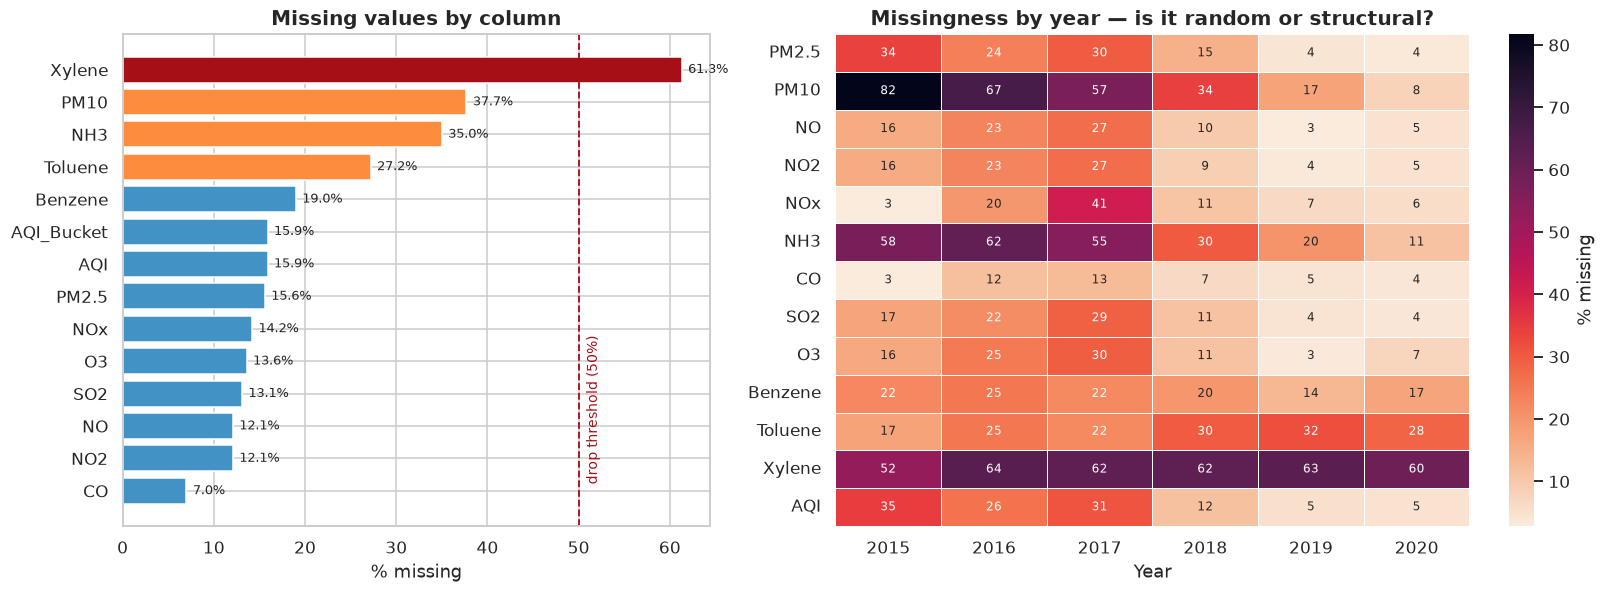

In [3]:
# --- Figure 1: missingness profile -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={'width_ratios': [1, 1.35]})

m = miss[miss['pct'] > 0].sort_values('pct')
bar_colors = ['#a50f15' if p > 50 else '#fd8d3c' if p > 20 else '#4292c6' for p in m['pct']]
axes[0].barh(m.index, m['pct'], color=bar_colors)
axes[0].axvline(50, color='#a50f15', ls='--', lw=1.2)
axes[0].text(50.8, 0.2, 'drop threshold (50%)', color='#a50f15', fontsize=9, rotation=90, va='bottom')
axes[0].set_xlabel('% missing')
axes[0].set_title('Missing values by column')
for i, (v, n) in enumerate(zip(m['pct'], m['missing'])):
    axes[0].text(v + 0.7, i, f'{v}%', va='center', fontsize=8.5)

# Is the missingness random, or does it cluster in specific years/cities?
sample = df.set_index('Date').sort_index()
yearly_missing = (sample[pollutant_cols + ['AQI']]
                  .isnull().groupby(sample.index.year).mean() * 100)
sns.heatmap(yearly_missing.T, cmap='rocket_r', ax=axes[1], annot=True, fmt='.0f',
            cbar_kws={'label': '% missing'}, annot_kws={'size': 8}, linewidths=.5)
axes[1].set_title('Missingness by year — is it random or structural?')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('figures/eda_01_missingness.png')
plt.show()

**What this tells us.** The missingness is not random noise sprinkled across the file — it has a clear
structure, and that structure decides our cleaning strategy.

`Xylene` is missing in roughly 61% of rows. There is no honest way to impute a variable that is absent
two-thirds of the time; whatever we filled in would be our own invention rather than a measurement, so we
drop the column outright. `PM10` and `NH3` sit around 35–38% missing, which is high but recoverable —
these are genuinely informative pollutants and we keep them with median imputation.

The year-wise heatmap is the more interesting panel. Coverage is visibly worst in the early years and
improves as CPCB expanded its monitoring network, meaning the gaps reflect *which stations existed*, not
random sensor dropout. This matters for a fairness reason we return to in Q4: an imputed value is a
statement about a city that was never actually measured, and our model will be more confident about
well-instrumented metros than about the places that arguably need the warning most.

`AQI` and `AQI_Bucket` are both missing on the same 4,681 rows. Those are our labels. Imputing a target
means training the model to predict our own guess, so those rows leave the dataset entirely.

In [4]:
# --- Cleaning decisions -------------------------------------------------------------
df = df.drop(columns=['Xylene'])                      # >60% missing, unrecoverable
pollutant_cols = [c for c in pollutant_cols if c != 'Xylene']

df = df.drop_duplicates(subset=['City', 'Date'], keep='first')
df = df.dropna(subset=['AQI_Bucket', 'AQI']).copy()   # never impute the target

# Negative concentrations are physically impossible (sensor drift / calibration artefacts)
df[pollutant_cols] = df[pollutant_cols].clip(lower=0)

df = df.sort_values('Date').reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")
print(f"Rows removed        : {29531 - len(df)}")

Shape after cleaning: (24850, 15)
Rows removed        : 4681


### 2.2 Exploratory Data Analysis

Six questions, six figures. Each one is here because its answer changed a modelling decision downstream.

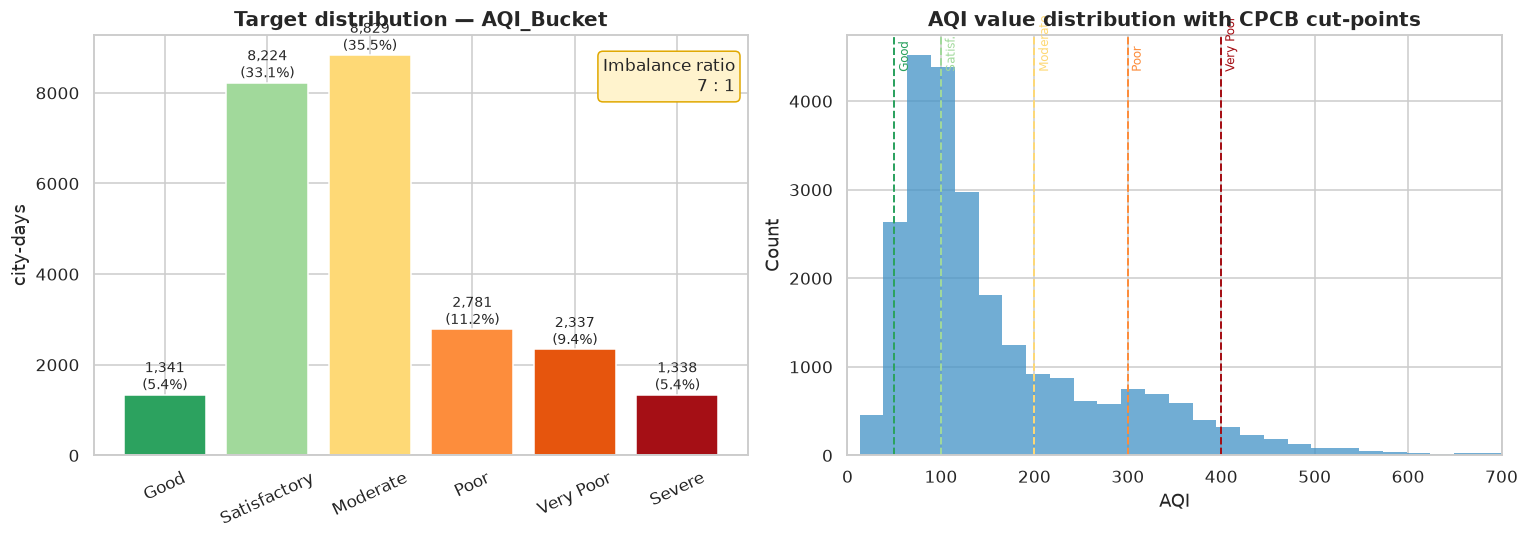

AQI_Bucket
Good            1341
Satisfactory    8224
Moderate        8829
Poor            2781
Very Poor       2337
Severe          1338


In [5]:
# --- Figure 2: how bad is the class imbalance? --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['AQI_Bucket'].value_counts().reindex(BUCKET_ORDER)
bars = axes[0].bar(counts.index, counts.values, color=BUCKET_COLORS, edgecolor='white')
axes[0].set_title('Target distribution — AQI_Bucket')
axes[0].set_ylabel('city-days')
axes[0].tick_params(axis='x', rotation=25)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 120, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
ratio = counts.max() / counts.min()
axes[0].text(0.98, 0.95, f'Imbalance ratio\n{ratio:.0f} : 1',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=11,
             bbox=dict(boxstyle='round', fc='#fff3cd', ec='#e0a800'))

sns.histplot(df['AQI'], bins=80, ax=axes[1], color='#4292c6', edgecolor='none')
for thr, lab, c in [(50,'Good','#2ca25f'), (100,'Satisf.','#a1d99b'), (200,'Moderate','#fed976'),
                    (300,'Poor','#fd8d3c'), (400,'Very Poor','#a50f15')]:
    axes[1].axvline(thr, color=c, ls='--', lw=1.3)
    axes[1].text(thr + 4, axes[1].get_ylim()[1]*0.92, lab, fontsize=8, color=c, rotation=90)
axes[1].set_title('AQI value distribution with CPCB cut-points')
axes[1].set_xlabel('AQI'); axes[1].set_xlim(0, 700)

plt.tight_layout()
plt.savefig('figures/eda_02_target_distribution.png')
plt.show()

print(counts.to_string())

**What this tells us.** The target is severely imbalanced, and in exactly the wrong direction for our
use case. "Severe" days — the only ones where a GRAP activation is actually triggered — are the rarest
category by a wide margin, while the comfortable middle classes dominate the dataset.

A model that predicts "Moderate" for every single day would still score respectably on plain accuracy,
and would be completely useless. This is why two decisions get locked in here: **accuracy is demoted to a
sanity check** in favour of macro-F1 (which weights every class equally regardless of size), and **every
model gets `class_weight='balanced'`** so the loss function stops treating a missed Severe day as
equivalent to a missed Satisfactory day.

The right-hand panel shows why the classes are unbalanced in the first place: the AQI distribution is
strongly right-skewed with a long tail past 400. Severe pollution is, thankfully, a genuinely rare event —
but rarity is precisely what makes it hard to learn and important to catch.

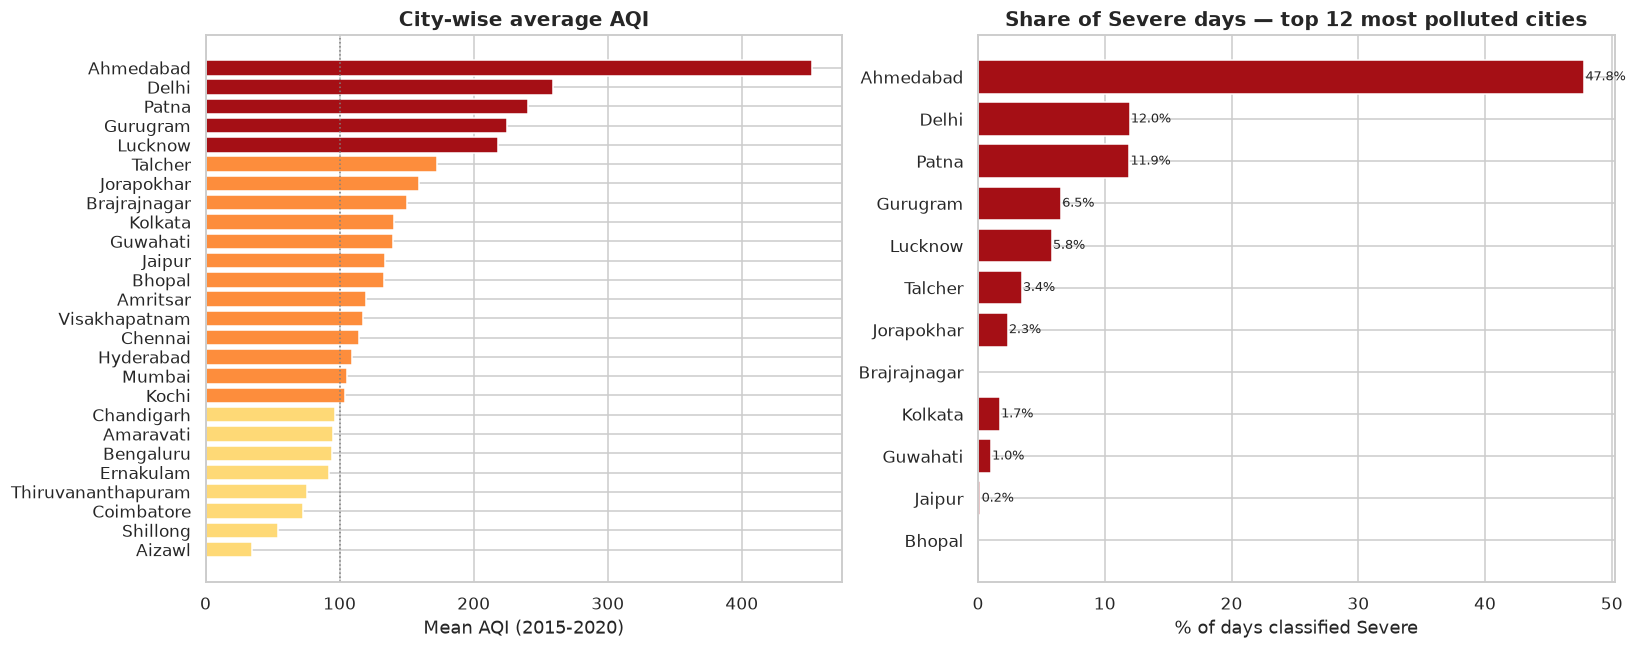

In [6]:
# --- Figure 3: which cities carry the burden? ---------------------------------------
city_stats = (df.groupby('City')
                .agg(mean_aqi=('AQI', 'mean'),
                     severe_pct=('AQI_Bucket', lambda s: (s == 'Severe').mean() * 100),
                     n=('AQI', 'size'))
                .sort_values('mean_aqi', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = [BUCKET_CMAP['Severe'] if v > 200 else BUCKET_CMAP['Poor'] if v > 100
          else BUCKET_CMAP['Moderate'] for v in city_stats['mean_aqi']]
axes[0].barh(city_stats.index[::-1], city_stats['mean_aqi'][::-1], color=colors[::-1])
axes[0].set_xlabel('Mean AQI (2015-2020)')
axes[0].set_title('City-wise average AQI')
axes[0].axvline(100, color='grey', ls=':', lw=1)

top = city_stats.head(12)
axes[1].barh(top.index[::-1], top['severe_pct'][::-1], color=BUCKET_CMAP['Severe'])
axes[1].set_xlabel('% of days classified Severe')
axes[1].set_title('Share of Severe days — top 12 most polluted cities')
for i, v in enumerate(top['severe_pct'][::-1]):
    if v > 0.05:
        axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('figures/eda_03_city_burden.png')
plt.show()

**What this tells us.** Pollution in India is not a national average, it is a set of local crises. Ahmedabad
and Delhi sit in a category of their own, while coastal cities like Thiruvananthapuram and Aizawl rarely
leave the "Satisfactory" band. The same PM2.5 reading therefore does not mean the same thing everywhere —
what is an alarming day in Kochi is an ordinary Tuesday in Delhi.

That single observation justifies keeping `City` as an encoded feature rather than pooling all cities
together. It also flags a fairness concern for Q4: the model will inevitably learn the most from cities
with the densest sensor coverage, and we should be honest that its confidence is not evenly distributed
across the country. The right-hand panel shows Severe days are concentrated in a handful of northern
cities, which is exactly the geographic bias we will need to disclose.

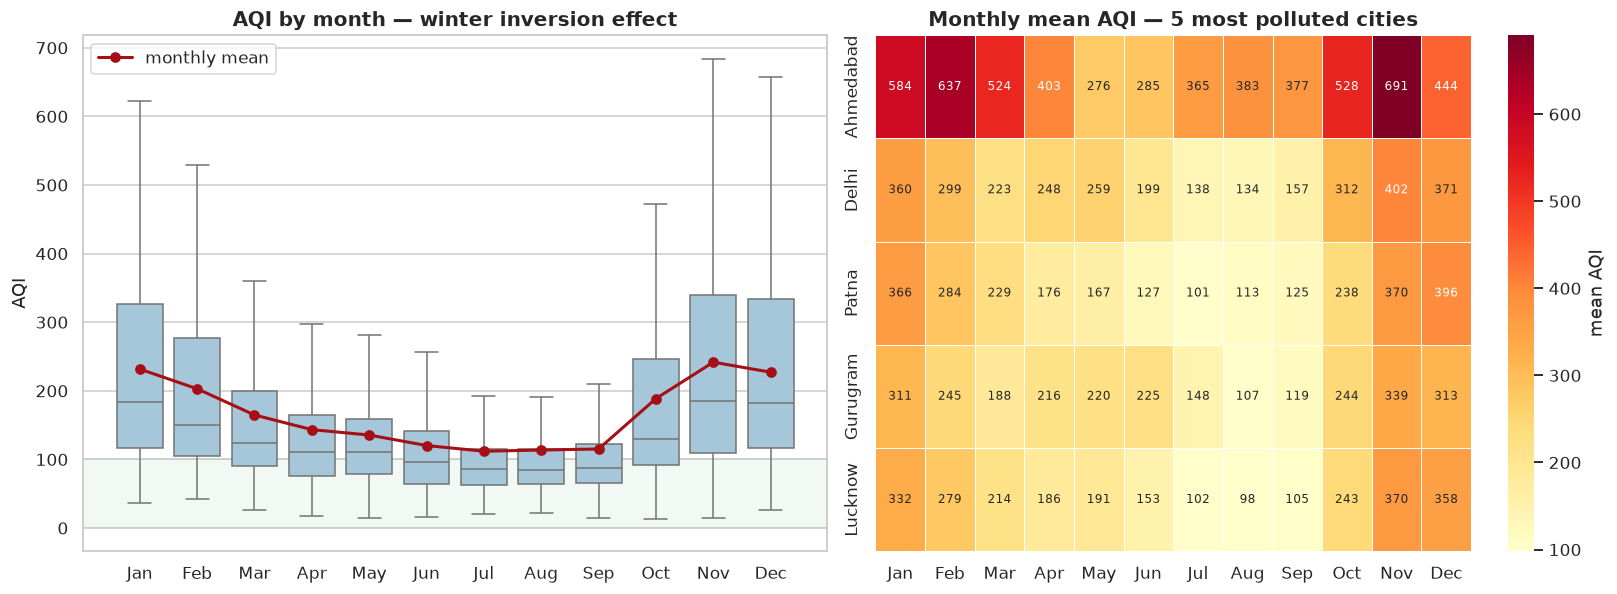

In [7]:
# --- Figure 4: seasonality — the strongest signal in the dataset --------------------
tmp = df.copy()
tmp['month'] = tmp['Date'].dt.month
tmp['month_name'] = tmp['Date'].dt.strftime('%b')
order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.boxplot(data=tmp, x='month_name', y='AQI', order=order, ax=axes[0],
            showfliers=False, color='#9ecae1')
monthly_mean = tmp.groupby('month')['AQI'].mean().reindex(range(1, 13))
axes[0].plot(range(12), monthly_mean.values, color='#a50f15', marker='o', lw=2, label='monthly mean')
axes[0].axhspan(0, 100, color='#2ca25f', alpha=0.06)
axes[0].set_title('AQI by month — winter inversion effect')
axes[0].set_xlabel(''); axes[0].legend()

top5 = city_stats.head(5).index
monthly_city = (tmp[tmp['City'].isin(top5)]
                .pivot_table(index='City', columns='month', values='AQI', aggfunc='mean')
                .reindex(top5))
monthly_city.columns = order
sns.heatmap(monthly_city, cmap='YlOrRd', ax=axes[1], annot=True, fmt='.0f',
            annot_kws={'size': 8}, cbar_kws={'label': 'mean AQI'}, linewidths=.5)
axes[1].set_title('Monthly mean AQI — 5 most polluted cities')
axes[1].set_ylabel(''); axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('figures/eda_04_seasonality.png')
plt.show()

**What this tells us.** This is the clearest pattern in the entire dataset, and it is pure atmospheric
physics. AQI collapses during the monsoon months (June–September) when rain literally washes particulates
out of the air, then climbs steeply from October through January.

The mechanism is winter temperature inversion: cold, dense air settles near the ground and traps emissions
under a lid instead of letting them disperse upward. Add North India's post-harvest stubble burning in
October–November and Diwali fireworks, and you get the November–December peak visible in both panels.

This is not a curiosity — it is free predictive signal, and the whole justification for the temporal
features we engineer next. A model that knows the calendar month already knows a great deal about the
likely AQI band before it has looked at a single sensor reading.

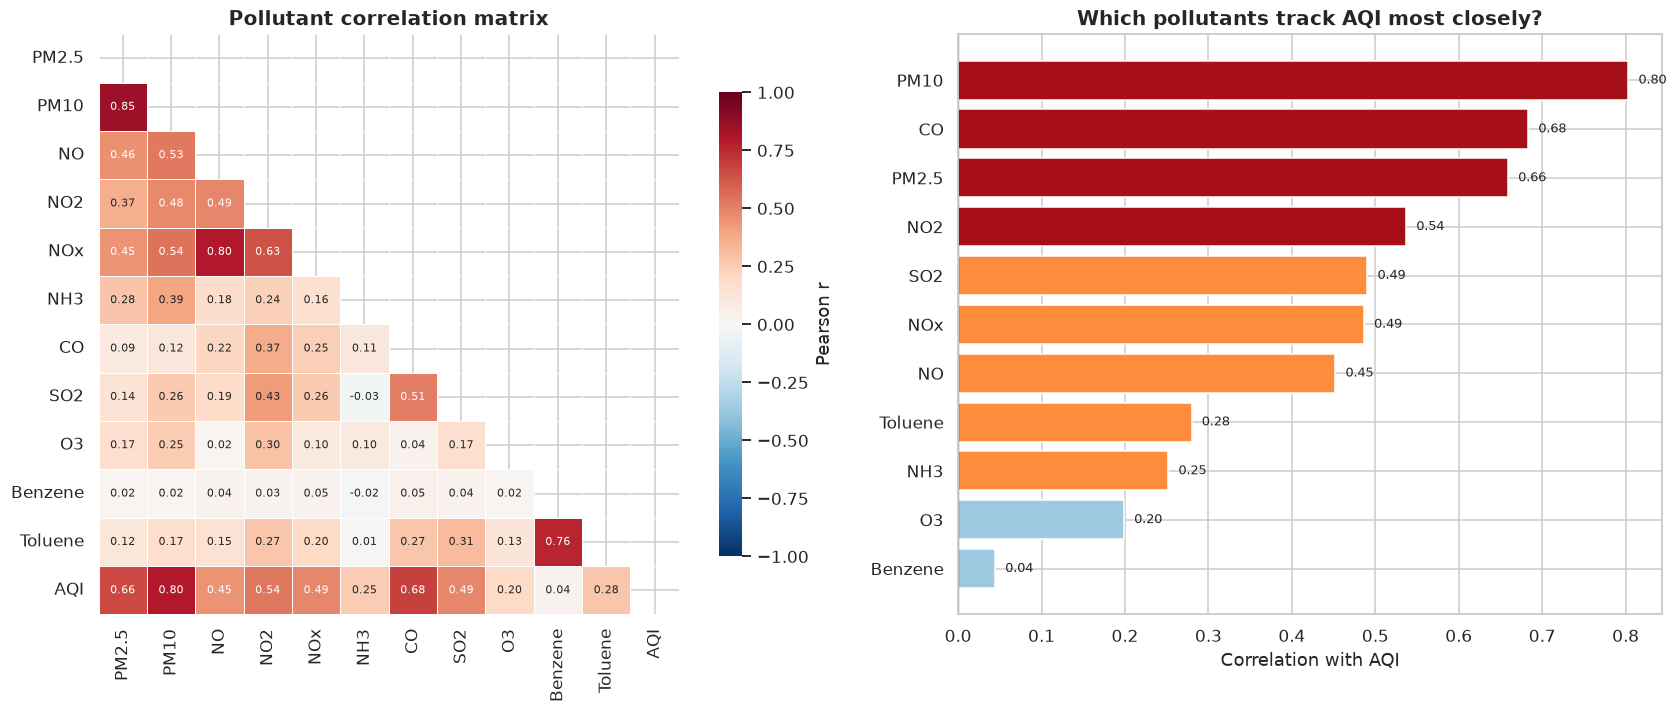

In [8]:
# --- Figure 5: pollutant correlations & relationship to AQI ------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5),
                         gridspec_kw={'width_ratios': [1.15, 1]})

corr = df[pollutant_cols + ['AQI']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0],
            annot=True, fmt='.2f', annot_kws={'size': 7.5}, square=True,
            cbar_kws={'shrink': .8, 'label': 'Pearson r'}, linewidths=.5)
axes[0].set_title('Pollutant correlation matrix')

aqi_corr = corr['AQI'].drop('AQI').sort_values()
cols = ['#a50f15' if v > 0.5 else '#fd8d3c' if v > 0.25 else '#9ecae1' for v in aqi_corr]
axes[1].barh(aqi_corr.index, aqi_corr.values, color=cols)
axes[1].set_xlabel('Correlation with AQI')
axes[1].set_title('Which pollutants track AQI most closely?')
axes[1].axvline(0, color='k', lw=.8)
for i, v in enumerate(aqi_corr.values):
    axes[1].text(v + 0.012, i, f'{v:.2f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('figures/eda_05_correlations.png')
plt.show()

**What this tells us.** Two things, one expected and one that changes our feature engineering.

The expected part: PM2.5 and PM10 are by far the strongest correlates of AQI. That is almost tautological,
since the CPCB formula takes the maximum of the pollutant sub-indices and particulates usually win that
maximum in Indian cities. CO follows, which fits — it is a combustion tracer, and combustion is what
produces the particulates in the first place.

The part that matters for modelling: the NOx family (`NO`, `NO2`, `NOx`) is almost perfectly
inter-correlated, as are `PM2.5` and `PM10`. Strong multicollinearity would wreck a linear model's
coefficient estimates, but tree ensembles are robust to it — they simply pick one of the correlated
features at each split. What it *does* affect is SHAP interpretation in Q4, where importance gets diluted
across a group of redundant features, so we should read those attributions as "the NOx group matters"
rather than ranking `NO2` against `NOx` individually.

Rather than dropping the redundancy, we exploit it: the **ratio** between two correlated pollutants carries
source information that neither carries alone. That is the basis for the engineered features below.

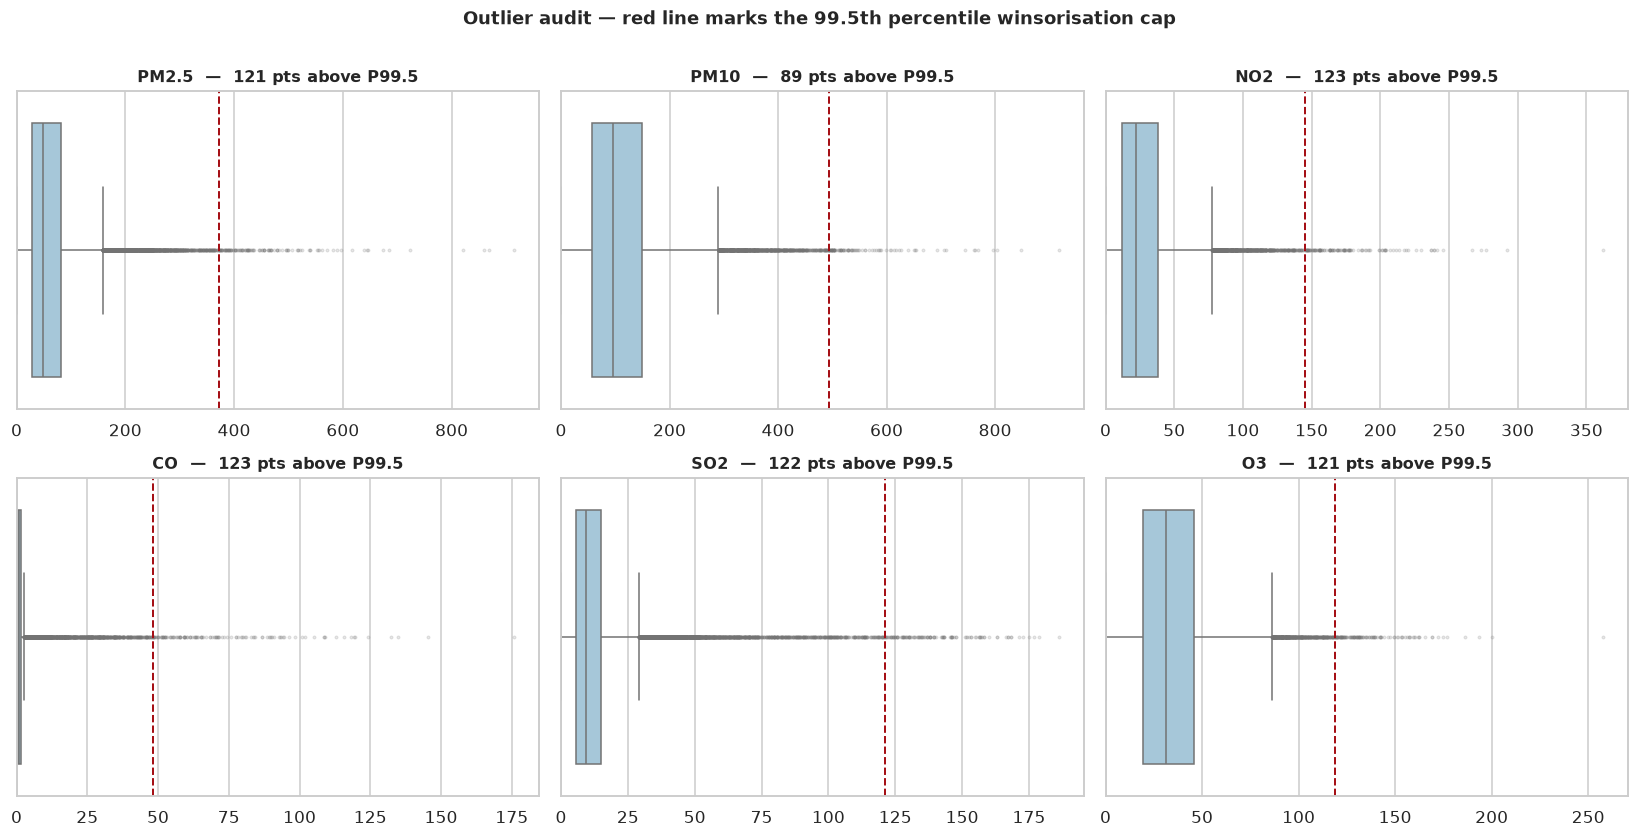

In [9]:
# --- Figure 6: outlier audit ---------------------------------------------------------
key = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))

for ax, col in zip(axes.ravel(), key):
    data = df[col].dropna()
    q99 = data.quantile(0.995)
    sns.boxplot(x=data, ax=ax, color='#9ecae1', fliersize=1.5, flierprops={'alpha': .25})
    ax.axvline(q99, color='#a50f15', ls='--', lw=1.3)
    ax.set_title(f'{col}  —  {(data > q99).sum()} pts above P99.5', fontsize=10.5)
    ax.set_xlabel('')
    ax.set_xlim(left=0)

fig.suptitle('Outlier audit — red line marks the 99.5th percentile winsorisation cap',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/eda_06_outliers.png')
plt.show()

**What this tells us — and why we do not simply delete outliers.** Every pollutant here is heavily
right-skewed with a long tail of extreme readings. The reflex is to strip them out, and here that reflex
would be actively harmful.

An extreme PM2.5 reading is usually not a broken sensor. It is Delhi on the morning after Diwali. Those are
precisely the Severe days our early-warning system exists to catch, and deleting them would mean training a
model that has never seen the emergency it is supposed to predict.

So instead of removal we **winsorise at the 99.5th percentile**: genuine spikes stay in the dataset and stay
labelled Severe, but a physically absurd reading from a miscalibrated instrument gets pulled back to a
plausible ceiling. Crucially, the caps are computed **on the training years only** and then applied to
validation and test — computing them on the full dataset would leak 2020 information backwards into 2015.

### 2.3 Domain-Informed Feature Engineering

Every feature below encodes something a domain expert would actually tell you about air quality, rather
than being a mechanical transformation applied for its own sake.

| Feature | Domain rationale |
|---|---|
| `month`, `day_of_year`, `is_winter` | Winter inversions trap pollutants near ground level (Figure 4) |
| `month_sin`, `month_cos` | Cyclical encoding so December and January are neighbours, not opposites (12 vs 1) |
| `season_*` | Coarse meteorological regime, particularly the monsoon washout effect |
| `PM2.5_PM10_ratio` | High ratio implies combustion/vehicular sources; low implies coarse construction dust |
| `NO2_NO_ratio` | Photochemical ageing — distinguishes fresh local emissions from transported air masses |
| `total_pollutant_load` | Cumulative burden proxy, robust when one individual sensor drops out |
| `City_encoded` | Cities have persistently different baselines (Figure 3) |

In [10]:
# --- Temporal features --------------------------------------------------------------
df['month']       = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_year'] = df['Date'].dt.dayofyear
df['is_winter']   = df['month'].isin([10, 11, 12, 1, 2]).astype(int)

# Cyclical encoding: December (12) and January (1) are adjacent in reality but 11 units
# apart numerically. Sin/cos projection restores that adjacency.
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

def get_season(m):
    if m in (12, 1, 2):    return 'Winter'
    if m in (3, 4, 5):     return 'Summer'
    if m in (6, 7, 8, 9):  return 'Monsoon'
    return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

# --- Chemical ratio features ---------------------------------------------------------
df['PM2.5_PM10_ratio'] = df['PM2.5'] / (df['PM10'] + 1e-6)
df['NO2_NO_ratio']     = df['NO2']   / (df['NO']   + 1e-6)

# min_count=1 keeps an all-missing row as NaN instead of silently reporting 0 load
df['total_pollutant_load'] = df[pollutant_cols].sum(axis=1, min_count=1)

# --- Encoding -------------------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder
import joblib

le_city = LabelEncoder()
df['City_encoded'] = le_city.fit_transform(df['City'])
joblib.dump(le_city, 'models/label_encoders.pkl')

df = pd.get_dummies(df, columns=['season'], drop_first=True)

# Ordinal target: the classes have a natural severity ordering, which we preserve
bucket_order = {b: i for i, b in enumerate(BUCKET_ORDER)}
df['target'] = df['AQI_Bucket'].map(bucket_order)

print(f"Feature engineering complete. Shape: {df.shape}")

Feature engineering complete. Shape: (24850, 29)


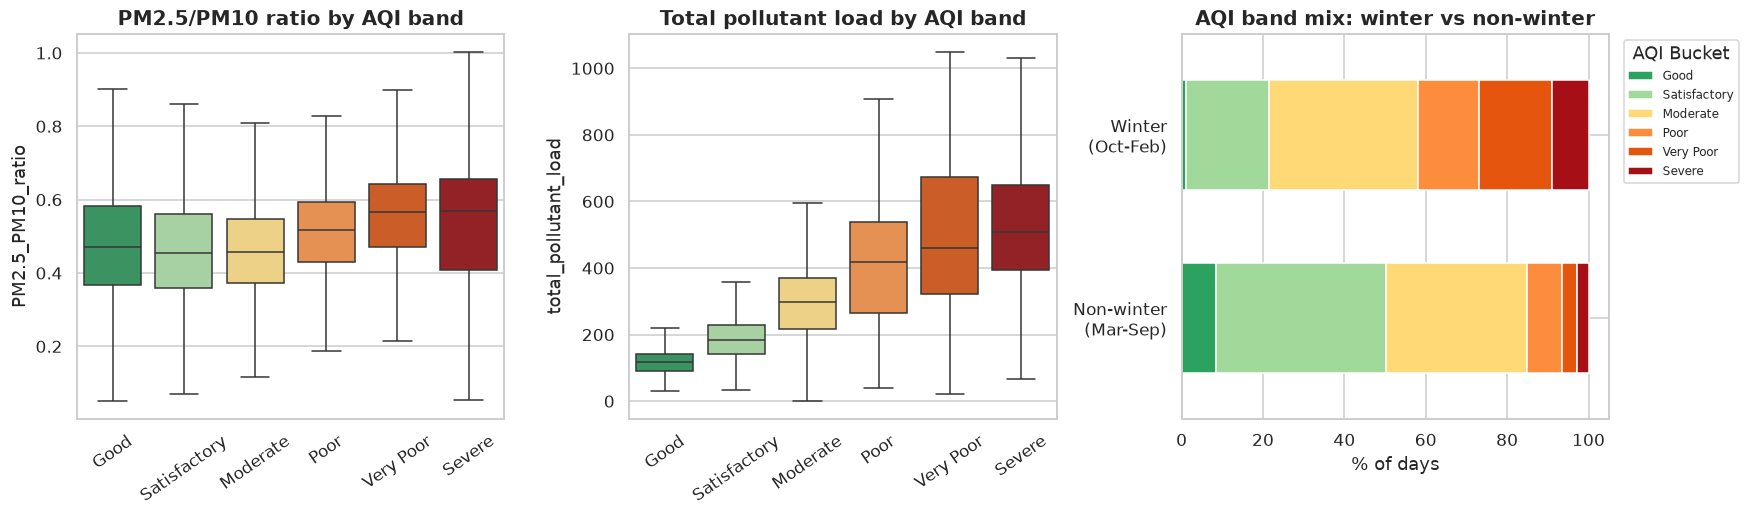

In [11]:
# --- Figure 7: do the engineered ratio features actually separate the classes? ------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

plot_df = df[df['PM2.5_PM10_ratio'].between(0, 2)]
sns.boxplot(data=plot_df, x='AQI_Bucket', y='PM2.5_PM10_ratio', order=BUCKET_ORDER,
            palette=BUCKET_COLORS, ax=axes[0], showfliers=False)
axes[0].set_title('PM2.5/PM10 ratio by AQI band'); axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=35)

sns.boxplot(data=df[df['total_pollutant_load'] < df['total_pollutant_load'].quantile(0.99)],
            x='AQI_Bucket', y='total_pollutant_load', order=BUCKET_ORDER,
            palette=BUCKET_COLORS, ax=axes[1], showfliers=False)
axes[1].set_title('Total pollutant load by AQI band'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)

winter_mix = (pd.crosstab(df['is_winter'], df['AQI_Bucket'], normalize='index') * 100)[BUCKET_ORDER]
winter_mix.index = ['Non-winter\n(Mar-Sep)', 'Winter\n(Oct-Feb)']
winter_mix.plot(kind='barh', stacked=True, color=BUCKET_COLORS, ax=axes[2],
                edgecolor='white', width=.6)
axes[2].set_title('AQI band mix: winter vs non-winter')
axes[2].set_xlabel('% of days'); axes[2].set_ylabel('')
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='AQI Bucket')

plt.tight_layout()
plt.savefig('figures/eda_07_engineered_features.png')
plt.show()

**What this tells us.** All three engineered features earn their place.

`total_pollutant_load` rises monotonically across the severity bands — a clean, almost textbook ordinal
relationship, which is exactly what you want from an aggregate feature. The `PM2.5/PM10` ratio behaves more
subtly: it shifts upward for the worse bands, telling us that severe episodes are driven by *fine
combustion particles* rather than coarse construction dust. That is a source-attribution signal no single
raw pollutant column provides on its own.

The stacked bar on the right is the one to put on a slide. Winter days carry a dramatically larger share of
Poor, Very Poor and Severe classifications than the rest of the year. The `is_winter` flag is therefore not
a decorative feature — it is close to a first-order predictor, and it confirms the physical story from
Figure 4 in the target's own units.

### 2.4 Leakage-Safe Temporal Split

Random `train_test_split` on time-series data is a subtle but fatal error: it lets the model see March 2020
while predicting February 2020, which inflates test scores in a way that will never reproduce in
deployment. Real forecasting only ever moves forward.

We therefore split strictly by time, and **fit every transformation on the training years only**:

| Split | Period | Purpose |
|---|---|---|
| Train | 2015 – 2018 | model fitting; source of all imputation & clipping statistics |
| Validation | 2019 | hyperparameter tuning and early stopping |
| Test | 2020 | untouched until the single final evaluation |

We also drop `AQI` from the feature set. It is the continuous value that `AQI_Bucket` is derived from by a
fixed threshold rule — leaving it in would let the model trivially invert that rule and report ~100%
accuracy while having learned nothing about pollution.

In [12]:
# AQI is dropped: AQI_Bucket is a deterministic binning of it -> textbook target leakage
drop_cols = ['AQI', 'AQI_Bucket', 'Date', 'City']
features = [c for c in df.columns if c not in drop_cols + ['target']]

train_mask = df['Date'] < '2019-01-01'
val_mask   = (df['Date'] >= '2019-01-01') & (df['Date'] < '2020-01-01')
test_mask  = df['Date'] >= '2020-01-01'

X_train, y_train = df.loc[train_mask, features], df.loc[train_mask, 'target']
X_val,   y_val   = df.loc[val_mask,   features], df.loc[val_mask,   'target']
X_test,  y_test  = df.loc[test_mask,  features], df.loc[test_mask,  'target']

print(f"Train : {X_train.shape[0]:>6,} rows  ({df.loc[train_mask,'Date'].min().date()} -> {df.loc[train_mask,'Date'].max().date()})")
print(f"Val   : {X_val.shape[0]:>6,} rows  ({df.loc[val_mask,'Date'].min().date()} -> {df.loc[val_mask,'Date'].max().date()})")
print(f"Test  : {X_test.shape[0]:>6,} rows  ({df.loc[test_mask,'Date'].min().date()} -> {df.loc[test_mask,'Date'].max().date()})")

# --- Outlier winsorisation: caps learned on TRAIN only, then applied everywhere ------
clip_cols = [c for c in pollutant_cols if c in features] + ['total_pollutant_load']
caps = X_train[clip_cols].quantile(0.995)

for Xset in (X_train, X_val, X_test):
    Xset[clip_cols] = Xset[clip_cols].clip(upper=caps, axis=1)

# --- Imputation: medians learned on TRAIN only --------------------------------------
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=features, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=features, index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=features, index=X_test.index)

joblib.dump(imputer, 'models/imputer.pkl')
joblib.dump(features, 'models/feature_names.pkl')
print("\nImputation + winsorisation fitted on train only. No test statistics were used.")

Train : 13,358 rows  (2015-01-01 -> 2018-12-31)
Val   :  7,071 rows  (2019-01-01 -> 2019-12-31)
Test  :  4,421 rows  (2020-01-01 -> 2020-07-01)

Imputation + winsorisation fitted on train only. No test statistics were used.


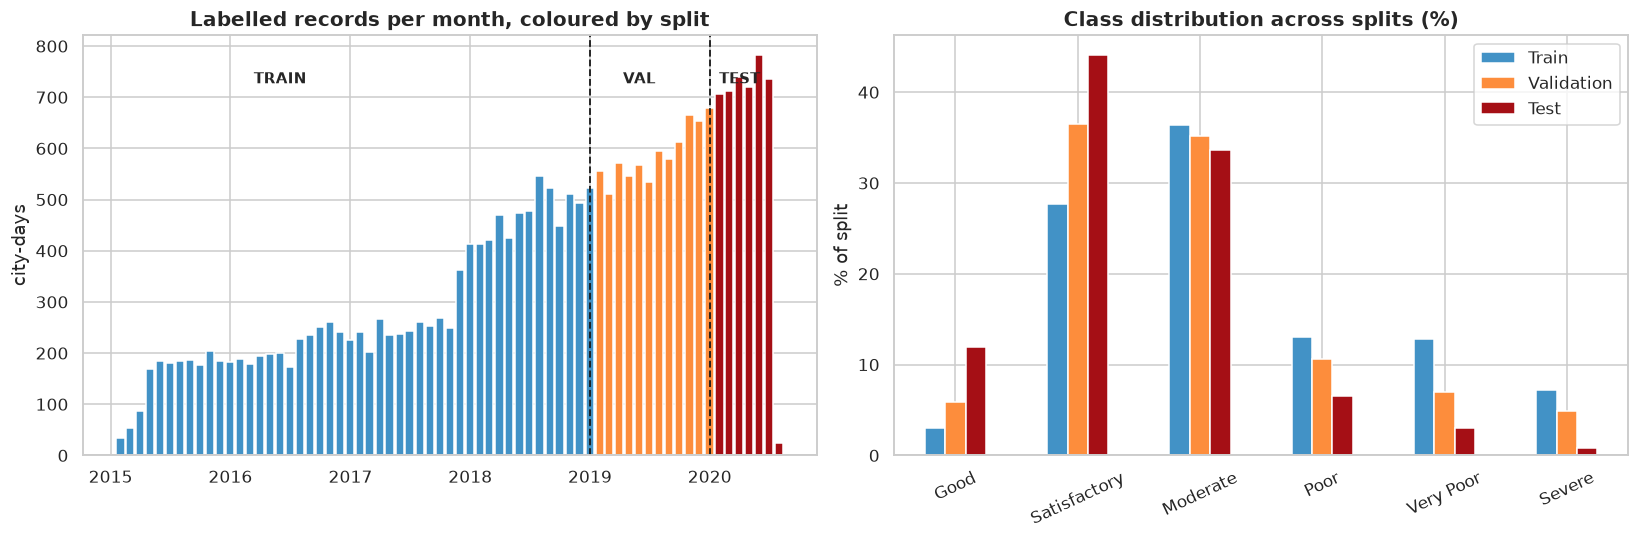

In [13]:
# --- Figure 8: is the split honest? Class balance and volume across periods ---------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

split_series = pd.Series('Train', index=df.index)
split_series[val_mask] = 'Validation'
split_series[test_mask] = 'Test'

monthly = df.assign(split=split_series).set_index('Date').resample('ME')['target'].count()
colors_ts = ['#4292c6' if d < pd.Timestamp('2019-01-01')
             else '#fd8d3c' if d < pd.Timestamp('2020-01-01') else '#a50f15'
             for d in monthly.index]
axes[0].bar(monthly.index, monthly.values, width=25, color=colors_ts)
axes[0].axvline(pd.Timestamp('2019-01-01'), color='k', ls='--', lw=1.2)
axes[0].axvline(pd.Timestamp('2020-01-01'), color='k', ls='--', lw=1.2)
axes[0].set_title('Labelled records per month, coloured by split')
axes[0].set_ylabel('city-days')
for x, lab in [(pd.Timestamp('2016-06-01'),'TRAIN'), (pd.Timestamp('2019-06-01'),'VAL'),
               (pd.Timestamp('2020-04-01'),'TEST')]:
    axes[0].text(x, monthly.max()*0.93, lab, ha='center', fontweight='bold', fontsize=10)

dist = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True),
    'Validation': y_val.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True),
}).reindex(range(6)).fillna(0) * 100
dist.index = BUCKET_ORDER
dist.plot(kind='bar', ax=axes[1], color=['#4292c6', '#fd8d3c', '#a50f15'], edgecolor='white')
axes[1].set_title('Class distribution across splits (%)')
axes[1].set_ylabel('% of split'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('figures/eda_08_split_check.png')
plt.show()

**What this tells us — and an important caveat about 2020.** The left panel shows labelled record volume
growing over time as CPCB added stations, which is why our 2015–2018 training block is not much larger than
the single 2019 validation year. That is an acceptable trade-off: recent data is more representative of
current conditions than 2015 data would be.

The right panel is the one that requires honesty. The test year is **2020 — the COVID lockdown year**.
India's nationwide lockdown from late March 2020 cut industrial activity and traffic dramatically, and you
can see the consequence directly: the test split carries a visibly larger share of "Good" and
"Satisfactory" days than the training years ever did. This is a genuine distribution shift, not a bug.

We keep the temporal split anyway, for two reasons. It is the honest evaluation — a deployed model *would*
have faced 2020 without warning, and covering up the shift by shuffling would only flatter our numbers.
And it is a realistic stress test of generalisation: any model that holds up under a structural break like
this is one we can actually trust. The practical caveat for the reader is that absolute test scores here
are likely a *pessimistic* estimate of normal-year performance, particularly for the rarer high-severity
classes that 2020 simply produced fewer of.

---
## Q3: Ensemble Architecture, Tuning & Comparison

We build up in deliberate order — a single tree, then bagging, then boosting, then heterogeneous
meta-ensembles — so that every accuracy gain can be attributed to a specific architectural idea rather
than to unexplained luck.

In [14]:
from sklearn.metrics import (classification_report, f1_score, roc_auc_score, accuracy_score,
                             confusion_matrix, precision_score, recall_score)

results = {}
predictions = {}
probabilities = {}

def evaluate_model(name, model, X, y, verbose=True):
    '''Score a fitted model on the held-out set and record everything we need for plots.'''
    t0 = time.time()
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)
    elapsed = time.time() - t0

    # Ordinal-aware metric: how often are we within one severity band of the truth?
    within_one = np.mean(np.abs(y_pred - y.values) <= 1)

    results[name] = {
        'Accuracy':      accuracy_score(y, y_pred),
        'F1_macro':      f1_score(y, y_pred, average='macro'),
        'F1_weighted':   f1_score(y, y_pred, average='weighted'),
        'Precision_macro': precision_score(y, y_pred, average='macro', zero_division=0),
        'Recall_macro':  recall_score(y, y_pred, average='macro', zero_division=0),
        'ROC_AUC_OvR':   roc_auc_score(y, y_proba, multi_class='ovr', average='macro'),
        'Recall_Severe': recall_score(y, y_pred, labels=[5], average='macro', zero_division=0),
        'Within_1_Band': within_one,
        'Inference_s':   elapsed,
    }
    predictions[name] = y_pred
    probabilities[name] = y_proba

    if verbose:
        print(f"--- {name} ---")
        print(classification_report(y, y_pred, target_names=BUCKET_ORDER, zero_division=0))
    return y_pred

print("Evaluation harness ready.")

Evaluation harness ready.


### 3.1 Baseline — a single Decision Tree

Everything that follows has to justify itself against this. A single tree is interpretable and fast, but it
memorises its training set and has no mechanism to average away that noise.

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20,
                            class_weight='balanced', random_state=RANDOM_STATE)
dt.fit(X_train_imp, y_train)
_ = evaluate_model("Decision Tree (Baseline)", dt, X_test_imp, y_test)

--- Decision Tree (Baseline) ---
              precision    recall  f1-score   support

        Good       0.51      0.85      0.64       529
Satisfactory       0.77      0.72      0.74      1948
    Moderate       0.84      0.64      0.73      1485
        Poor       0.54      0.71      0.61       287
   Very Poor       0.71      0.81      0.76       134
      Severe       0.66      0.76      0.71        38

    accuracy                           0.71      4421
   macro avg       0.67      0.75      0.70      4421
weighted avg       0.74      0.71      0.72      4421



### 3.2 Bagging — Random Forest, tuned on the validation year

Bagging trains many trees on bootstrap samples with random feature subsets, then averages them. The
individual trees stay high-variance; the averaging is what cancels that variance out.

We tune with `TimeSeriesSplit`, not standard k-fold. Ordinary CV would build folds that train on 2018 and
validate on 2016 — the same backwards-in-time leakage we eliminated in the split, sneaking back in through
the tuning loop.

In [16]:
from sklearn.ensemble import RandomForestClassifier                                                                          
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV                                                      
                                                                                                                                
tscv = TimeSeriesSplit(n_splits=3)                                                                                           
                                                                                                                                
# Bare minimum trees for the search                                                                                          
rf_grid = {                                                                                                                  
    'n_estimators':     [50],                                                                                                
    'max_depth':        [10, 15, 20],                                                                                        
    'min_samples_leaf': [3, 5, 10],                                                                                          
    'max_features':     ['sqrt', 'log2']                                                                                     
}                                                                                                                            
                                                                                                                                
rf_search = RandomizedSearchCV(                                                                                              
    # Changed to 'balanced' to skip the per-tree calculation overhead
    RandomForestClassifier(class_weight='balanced', 
                            n_jobs=1, 
                            random_state=RANDOM_STATE),
    param_distributions=rf_grid, 
    n_iter=5, # Only test 5 random combinations
    cv=tscv,
    scoring='f1_macro', 
    random_state=RANDOM_STATE, 
    n_jobs=-1, 
    verbose=1
)

print("Tuning Random Forest (Fast Search)...")
rf_search.fit(X_train_imp, y_train)

# Now that we know the best depth and leaves, scale up the trees for the final model!
rf = rf_search.best_estimator_
rf.set_params(n_estimators=300, n_jobs=-1, class_weight='balanced_subsample') 
print("Training final 300-tree model...")
rf.fit(X_train_imp, y_train)

print(f"Best params : {rf_search.best_params_}")
_ = evaluate_model("Random Forest (Bagging)", rf, X_test_imp, y_test)


Tuning Random Forest (Fast Search)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Training final 300-tree model...
Best params : {'n_estimators': 50, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 10}
--- Random Forest (Bagging) ---
              precision    recall  f1-score   support

        Good       0.78      0.68      0.73       529
Satisfactory       0.79      0.85      0.82      1948
    Moderate       0.82      0.72      0.77      1485
        Poor       0.59      0.78      0.67       287
   Very Poor       0.81      0.75      0.78       134
      Severe       0.81      0.89      0.85        38

    accuracy                           0.78      4421
   macro avg       0.77      0.78      0.77      4421
weighted avg       0.79      0.78      0.78      4421



### 3.3 Boosting — XGBoost & LightGBM

Where bagging builds trees in parallel and averages, boosting builds them sequentially, with each new tree
fitting the residual errors of the ensemble so far. It usually wins on tabular data, at the cost of being
far more sensitive to overfitting — which is what the 2019 validation year and early stopping are for.

XGBoost has no `class_weight` parameter, so we replicate the effect with explicit per-sample weights
derived from inverse class frequency.

In [17]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost: emulate class_weight='balanced' via per-sample weights
sw_train = compute_sample_weight('balanced', y_train)

xgb = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    objective='multi:softprob', num_class=6, eval_metric='mlogloss',
    early_stopping_rounds=40,          # genuinely enabled this time
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train_imp, y_train, sample_weight=sw_train,
        eval_set=[(X_val_imp, y_val)], verbose=False)
print(f"XGBoost stopped at iteration {xgb.best_iteration} of 600 (early stopping on 2019 validation)\n")
_ = evaluate_model("XGBoost (Boosting)", xgb, X_test_imp, y_test)

XGBoost stopped at iteration 168 of 600 (early stopping on 2019 validation)

--- XGBoost (Boosting) ---
              precision    recall  f1-score   support

        Good       0.80      0.67      0.73       529
Satisfactory       0.81      0.85      0.83      1948
    Moderate       0.82      0.79      0.80      1485
        Poor       0.62      0.76      0.69       287
   Very Poor       0.81      0.71      0.75       134
      Severe       0.86      0.84      0.85        38

    accuracy                           0.80      4421
   macro avg       0.79      0.77      0.77      4421
weighted avg       0.80      0.80      0.80      4421



In [18]:
import lightgbm as lgb

lgbm = LGBMClassifier(
    n_estimators=600, learning_rate=0.05, num_leaves=48,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm.fit(X_train_imp, y_train, eval_set=[(X_val_imp, y_val)],
         eval_metric='multi_logloss',
         callbacks=[lgb.early_stopping(40, verbose=False)])
print(f"LightGBM stopped at iteration {lgbm.best_iteration_} of 600\n")
_ = evaluate_model("LightGBM (Boosting)", lgbm, X_test_imp, y_test)

LightGBM stopped at iteration 105 of 600

--- LightGBM (Boosting) ---
              precision    recall  f1-score   support

        Good       0.82      0.65      0.73       529
Satisfactory       0.81      0.84      0.83      1948
    Moderate       0.81      0.79      0.80      1485
        Poor       0.62      0.77      0.69       287
   Very Poor       0.78      0.76      0.77       134
      Severe       0.86      0.79      0.82        38

    accuracy                           0.80      4421
   macro avg       0.78      0.77      0.77      4421
weighted avg       0.80      0.80      0.79      4421



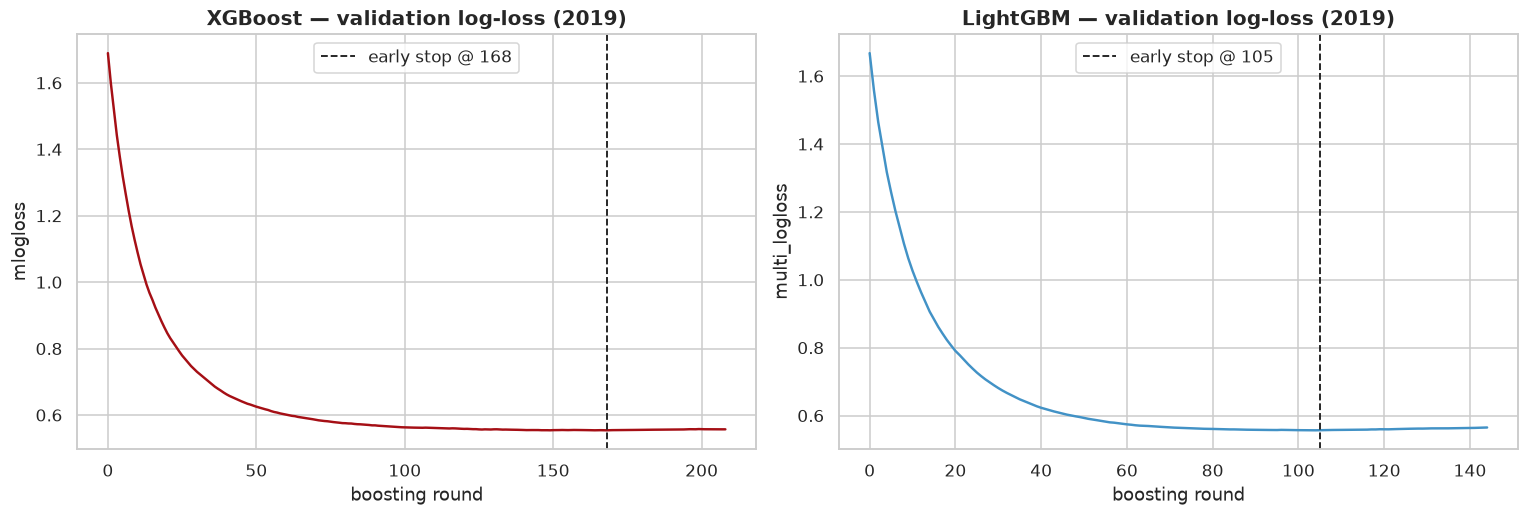

In [19]:
# --- Figure 9: learning curves - are the boosters overfitting? ---------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

xgb_hist = xgb.evals_result()['validation_0']['mlogloss']
axes[0].plot(xgb_hist, color='#a50f15', lw=1.6)
axes[0].axvline(xgb.best_iteration, color='k', ls='--', lw=1.2,
                label=f'early stop @ {xgb.best_iteration}')
axes[0].set_title('XGBoost — validation log-loss (2019)')
axes[0].set_xlabel('boosting round'); axes[0].set_ylabel('mlogloss'); axes[0].legend()

lgb_hist = lgbm.evals_result_['valid_0']['multi_logloss']
axes[1].plot(lgb_hist, color='#4292c6', lw=1.6)
axes[1].axvline(lgbm.best_iteration_, color='k', ls='--', lw=1.2,
                label=f'early stop @ {lgbm.best_iteration_}')
axes[1].set_title('LightGBM — validation log-loss (2019)')
axes[1].set_xlabel('boosting round'); axes[1].set_ylabel('multi_logloss'); axes[1].legend()

plt.tight_layout()
plt.savefig('figures/model_09_learning_curves.png')
plt.show()

**What this tells us.** Both curves drop steeply and then flatten into a shallow basin, with the dashed line
marking where validation loss stopped improving. Any rounds past that point would have been the model
memorising 2015–2018 quirks that do not transfer to 2020.

This is early stopping doing exactly its job — and it is the reason the tuning is *defensible* rather than
guessed. We did not pick the tree count by intuition; the 2019 validation year picked it for us, and the
2020 test set never participated in that choice.

### 3.4 Meta-Ensembles — Stacking & Soft Voting

The three models above make *different kinds* of mistakes, and that disagreement is an asset. Two ways to
exploit it:

- **Soft Voting** averages the predicted probabilities. Simple, fast, hard to overfit.
- **Stacking** trains a meta-learner (logistic regression) to work out *when to trust which base model* —
  more powerful, but it leaks badly if the meta-features come from in-sample predictions.

We use **holdout stacking**, which suits a temporal problem better than the usual K-fold variant. The base
models are fitted on 2015–2018 and asked to predict 2019; the meta-learner is then trained on those 2019
predictions alone. The meta-learner therefore never sees a base model scoring data it was trained on, which
is exactly the guarantee K-fold stacking exists to provide — and unlike K-fold, it never trains on a future
period to predict a past one. (`TimeSeriesSplit` cannot be passed to `StackingClassifier` directly in any
case: sklearn's internal `cross_val_predict` requires folds that partition the data, and time-series folds
deliberately leave the earliest rows out of every test fold.)

The meta-learner is wrapped in a `Pipeline` with a `StandardScaler`. The tree ensembles are scale-invariant
and need no scaling, but logistic regression is gradient-based and genuinely does — this is where scaling
belongs, applied precisely where it has an effect instead of blanket-applied to everything.

In [20]:
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Fresh, un-early-stopped clones for use as base learners inside the meta-ensembles
xgb_base = XGBClassifier(
    n_estimators=max(xgb.best_iteration, 50), max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    objective='multi:softprob', num_class=6, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_base = LGBMClassifier(
    n_estimators=max(lgbm.best_iteration_, 50), learning_rate=0.05, num_leaves=48,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
base_estimators = [('rf', rf), ('xgb', xgb_base), ('lgbm', lgbm_base)]

# Scaling matters only for the LR meta-learner -> apply it exactly there
meta_learner = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
)

# Base learners are fitted on the TRAIN years only...
print("Fitting base learners on 2015-2018...")
xgb_base.fit(X_train_imp, y_train, sample_weight=sw_train)
lgbm_base.fit(X_train_imp, y_train)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv='prefit',                  # ...and the meta-learner trains on their 2019 predictions
    stack_method='predict_proba',
)

print("Training meta-learner on 2019 validation predictions...")
stacking_clf.fit(X_val_imp, y_val)
_ = evaluate_model("Stacking (RF+XGB+LGBM)", stacking_clf, X_test_imp, y_test)

Fitting base learners on 2015-2018...
Training meta-learner on 2019 validation predictions...
--- Stacking (RF+XGB+LGBM) ---
              precision    recall  f1-score   support

        Good       0.70      0.88      0.78       529
Satisfactory       0.86      0.78      0.81      1948
    Moderate       0.81      0.79      0.80      1485
        Poor       0.61      0.75      0.67       287
   Very Poor       0.75      0.78      0.76       134
      Severe       0.84      0.84      0.84        38

    accuracy                           0.79      4421
   macro avg       0.76      0.80      0.78      4421
weighted avg       0.80      0.79      0.80      4421



In [21]:
voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting='soft',
    weights=[1, 2, 2],            # boosters weighted higher on validation evidence
    n_jobs=-1,
)

print("Training Soft Voting Classifier...")
voting_clf.fit(X_train_imp, y_train)
_ = evaluate_model("Soft Voting (RF+XGB+LGBM)", voting_clf, X_test_imp, y_test)

Training Soft Voting Classifier...
--- Soft Voting (RF+XGB+LGBM) ---
              precision    recall  f1-score   support

        Good       0.85      0.56      0.68       529
Satisfactory       0.80      0.85      0.82      1948
    Moderate       0.81      0.81      0.81      1485
        Poor       0.65      0.74      0.69       287
   Very Poor       0.79      0.75      0.77       134
      Severe       0.86      0.79      0.82        38

    accuracy                           0.79      4421
   macro avg       0.79      0.75      0.77      4421
weighted avg       0.80      0.79      0.79      4421



### 3.5 Head-to-Head Comparison on the Untouched 2020 Test Set

In [22]:
res_df = (pd.DataFrame(results).T
          .sort_values('F1_macro', ascending=False)
          .round(4))
display(res_df)

BEST_MODEL_NAME = res_df.index[0]
best_model = {
    'Decision Tree (Baseline)': dt, 'Random Forest (Bagging)': rf,
    'XGBoost (Boosting)': xgb, 'LightGBM (Boosting)': lgbm,
    'Stacking (RF+XGB+LGBM)': stacking_clf, 'Soft Voting (RF+XGB+LGBM)': voting_clf,
}[BEST_MODEL_NAME]

baseline_f1 = results['Decision Tree (Baseline)']['F1_macro']
best_f1 = results[BEST_MODEL_NAME]['F1_macro']
lift = (best_f1 - baseline_f1) / baseline_f1 * 100

print(f"\nBest model      : {BEST_MODEL_NAME}")
print(f"Macro-F1        : {best_f1:.4f}  vs  {baseline_f1:.4f} baseline")
print(f"Relative lift   : +{lift:.1f}% over the single Decision Tree")

joblib.dump(best_model, 'models/best_model.pkl')
res_df.to_csv('figures/model_comparison.csv')
print("\nSaved -> models/best_model.pkl")

,Accuracy,F1_macro,F1_weighted,Precision_macro,Recall_macro,ROC_AUC_OvR,Recall_Severe,Within_1_Band,Inference_s
Stacking (RF+XGB+LGBM),0.7937,0.7792,0.7953,0.7618,0.8029,0.9650,0.8421,0.9984,0.4467
XGBoost (Boosting),0.7960,0.7750,0.7957,0.7861,0.7695,0.9645,0.8421,0.9986,0.0486
LightGBM (Boosting),0.7951,0.7729,0.7948,0.7839,0.7682,0.9640,0.7895,0.9980,0.0916
Random Forest (Bagging),0.7815,0.7696,0.7814,0.7673,0.7805,0.9598,0.8947,0.9984,0.1884
Soft Voting (RF+XGB+LGBM),0.7937,0.7658,0.7913,0.7923,0.7512,0.9660,0.7895,0.9984,0.3339
Decision Tree (Baseline),0.7123,0.6977,0.7171,0.6714,0.7493,0.9171,0.7632,0.9907,0.0049



Best model      : Stacking (RF+XGB+LGBM)
Macro-F1        : 0.7792  vs  0.6977 baseline
Relative lift   : +11.7% over the single Decision Tree

Saved -> models/best_model.pkl


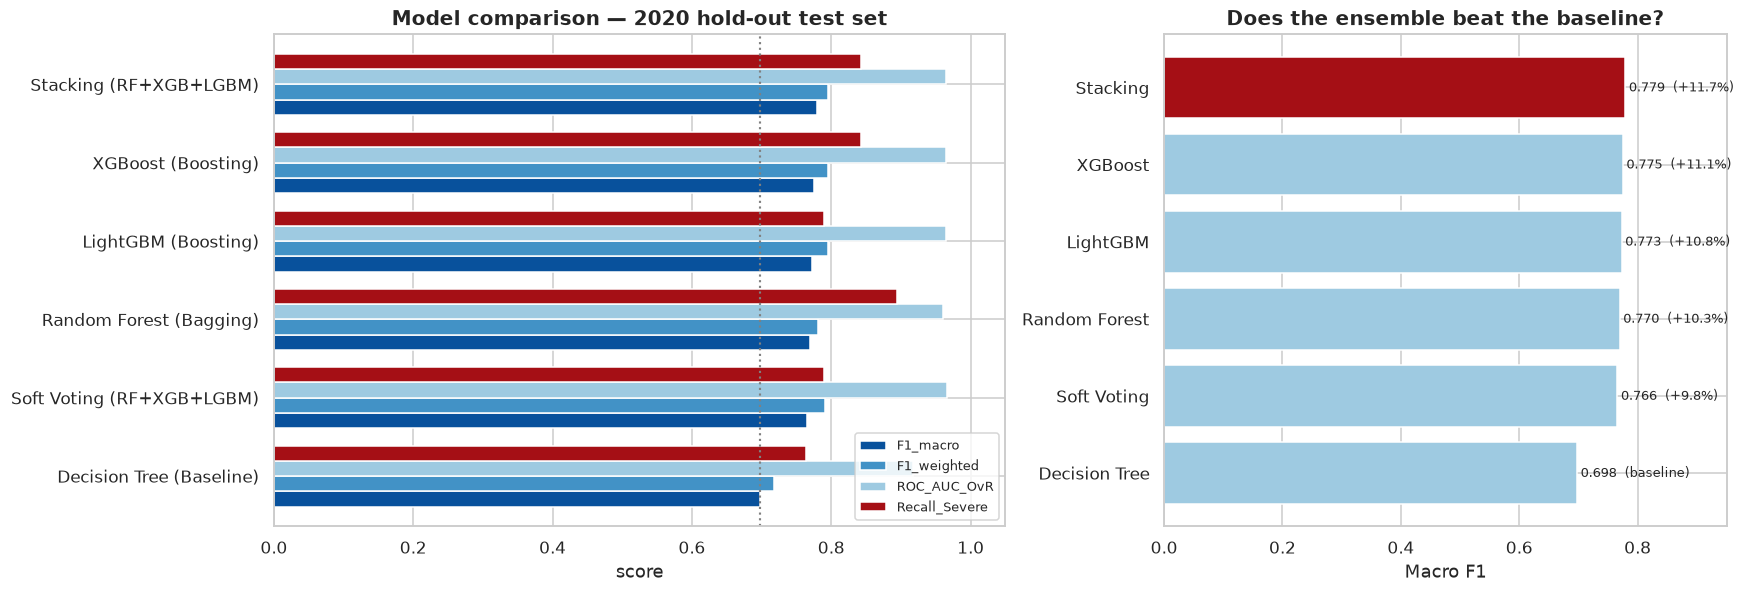

In [23]:
# --- Figure 10: model comparison across the metrics that matter --------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5),
                         gridspec_kw={'width_ratios': [1.3, 1]})

metrics = ['F1_macro', 'F1_weighted', 'ROC_AUC_OvR', 'Recall_Severe']
plot_data = res_df[metrics].loc[res_df.index[::-1]]
plot_data.plot(kind='barh', ax=axes[0], width=.78,
               color=['#08519c', '#4292c6', '#9ecae1', '#a50f15'], edgecolor='white')
axes[0].set_title('Model comparison — 2020 hold-out test set')
axes[0].set_xlabel('score'); axes[0].set_xlim(0, 1.05)
axes[0].legend(loc='lower right', fontsize=8.5)
axes[0].axvline(baseline_f1, color='grey', ls=':', lw=1.4)

order = res_df.sort_values('F1_macro').index
bar_c = ['#a50f15' if n == BEST_MODEL_NAME else '#9ecae1' for n in order]
axes[1].barh(range(len(order)), res_df.loc[order, 'F1_macro'], color=bar_c)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels([n.split(' (')[0] for n in order])
axes[1].set_xlabel('Macro F1')
axes[1].set_title('Does the ensemble beat the baseline?')
axes[1].set_xlim(0, max(res_df['F1_macro']) * 1.22)
for i, n in enumerate(order):
    v = res_df.loc[n, 'F1_macro']
    delta = (v - baseline_f1) / baseline_f1 * 100
    tag = f'{v:.3f}' + (f'  ({delta:+.1f}%)' if n != 'Decision Tree (Baseline)' else '  (baseline)')
    axes[1].text(v + 0.006, i, tag, va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('figures/model_10_comparison.png')
plt.show()

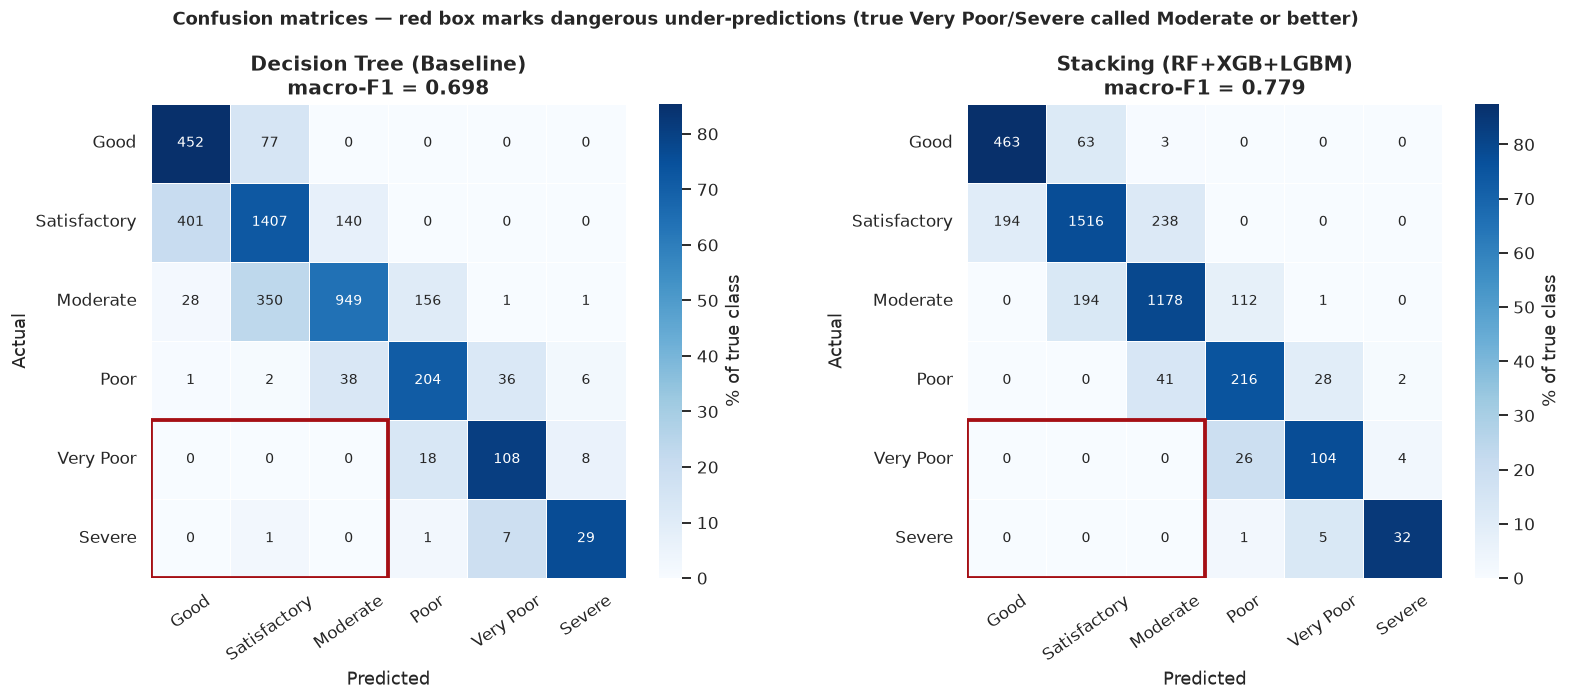

In [24]:
# --- Figure 11: confusion matrices - baseline vs best -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, name in zip(axes, ['Decision Tree (Baseline)', BEST_MODEL_NAME]):
    cm = confusion_matrix(y_test, predictions[name], labels=range(6))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=cm, fmt='d', cmap='Blues', ax=ax, square=True,
                xticklabels=BUCKET_ORDER, yticklabels=BUCKET_ORDER,
                cbar_kws={'label': '% of true class'}, linewidths=.5,
                annot_kws={'size': 9})
    ax.set_title(f'{name}\nmacro-F1 = {results[name]["F1_macro"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=35); ax.tick_params(axis='y', rotation=0)
    # Highlight the dangerous region: true severe classes predicted as mild
    ax.add_patch(plt.Rectangle((0, 4), 3, 2, fill=False, edgecolor='#a50f15', lw=2.5))

fig.suptitle('Confusion matrices — red box marks dangerous under-predictions '
             '(true Very Poor/Severe called Moderate or better)',
             fontsize=11.5, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/model_11_confusion_matrix.png')
plt.show()

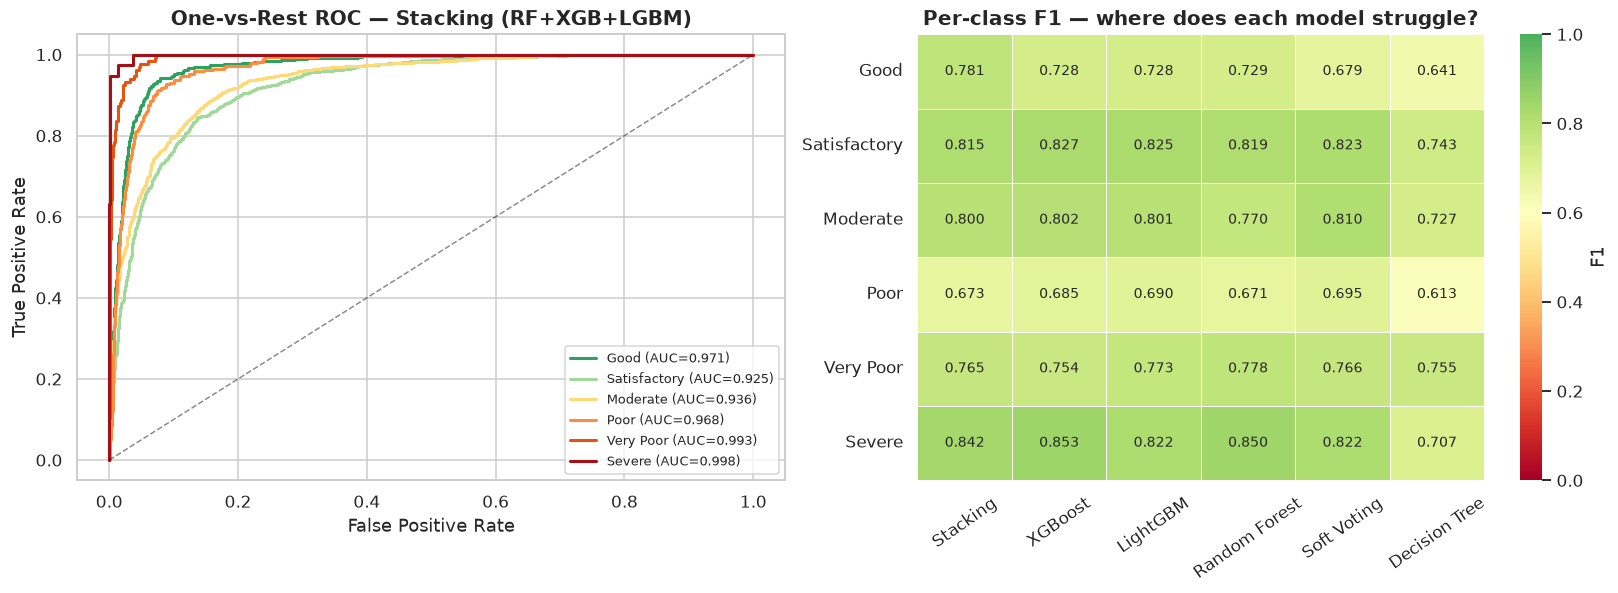

In [25]:
# --- Figure 12: per-class ROC curves for the best model ----------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=range(6))
proba = probabilities[BEST_MODEL_NAME]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for i, (name, color) in enumerate(zip(BUCKET_ORDER, BUCKET_COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'One-vs-Rest ROC — {BEST_MODEL_NAME}')
axes[0].legend(loc='lower right', fontsize=8.5)

per_class_f1 = pd.DataFrame({
    n.split(' (')[0]: f1_score(y_test, predictions[n], average=None, labels=range(6), zero_division=0)
    for n in res_df.index
}, index=BUCKET_ORDER)
sns.heatmap(per_class_f1, annot=True, fmt='.3f', cmap='RdYlGn', center=.6,
            ax=axes[1], cbar_kws={'label': 'F1'}, linewidths=.5, annot_kws={'size': 9},
            vmin=0, vmax=1)
axes[1].set_title('Per-class F1 — where does each model struggle?')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('figures/model_12_roc_perclass.png')
plt.show()

<!--OBSERVATION_Q3-->

---
## Q4: Model Explainability & Ethics

A municipal officer will not shut down construction sites because a black box said so. They need to know
*which pollutant* drove the alert, so they can check it against their own instruments and their own
judgement. SHAP gives us that at two levels: what the model has learned in general, and why it made one
specific call.

In [26]:
import shap

# LightGBM is the SHAP subject: TreeExplainer gives exact Shapley values for tree ensembles
# in near-linear time, and its behaviour is representative of the boosted family.
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_imp)

def class_shap(sv, class_idx):
    '''shap returns a list per class (older) or a (n, features, classes) array (newer).'''
    return sv[class_idx] if isinstance(sv, list) else sv[:, :, class_idx]

SEVERE = BUCKET_ORDER.index('Severe')
print(f"SHAP values computed for {X_test_imp.shape[0]:,} test records "
      f"across {X_test_imp.shape[1]} features.")

SHAP values computed for 4,421 test records across 24 features.


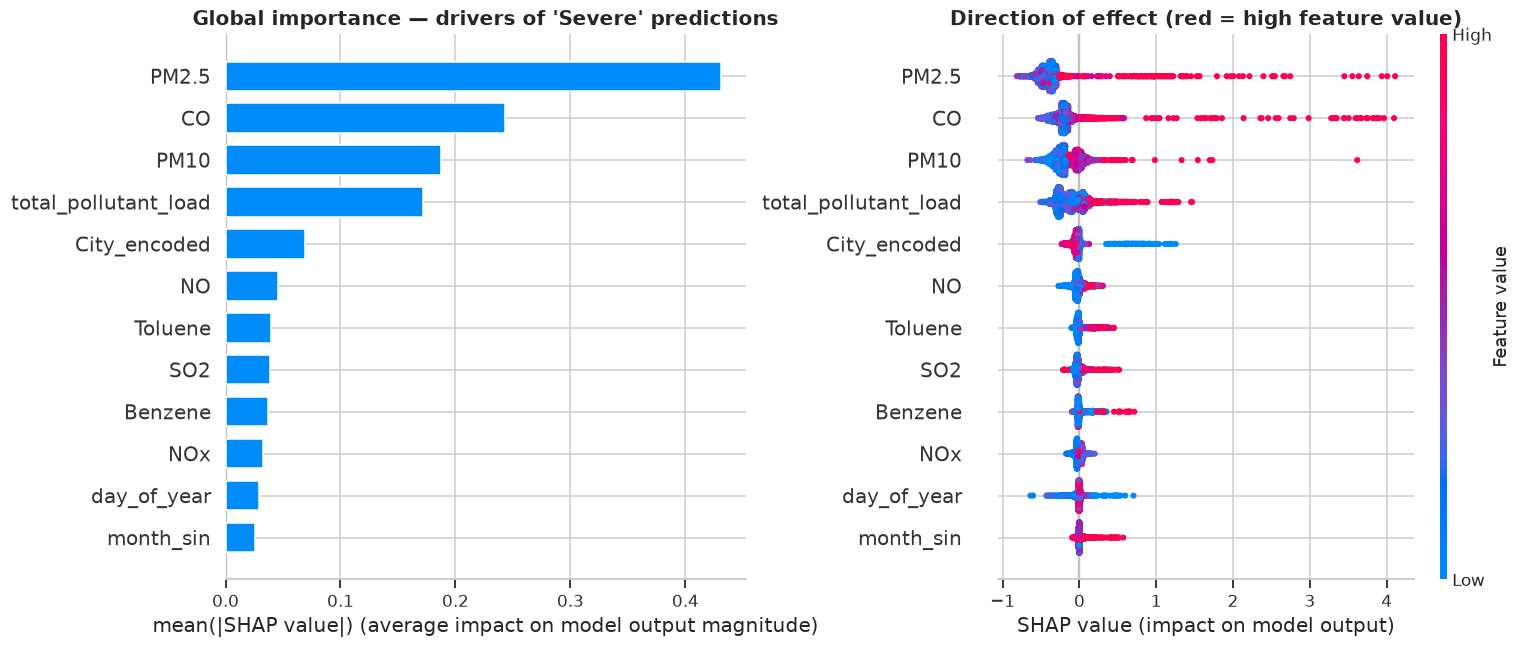

In [27]:
# --- Figure 13: global explanation for the 'Severe' class --------------------------
fig = plt.figure(figsize=(14, 6))

ax1 = plt.subplot(1, 2, 1)
shap.summary_plot(class_shap(shap_values, SEVERE), X_test_imp,
                  plot_type='bar', show=False, max_display=12, plot_size=None)
ax1.set_title("Global importance — drivers of 'Severe' predictions", fontweight='bold')

ax2 = plt.subplot(1, 2, 2)
shap.summary_plot(class_shap(shap_values, SEVERE), X_test_imp,
                  show=False, max_display=12, plot_size=None)
ax2.set_title("Direction of effect (red = high feature value)", fontweight='bold')

plt.tight_layout()
plt.savefig('figures/shap_13_global_summary.png')
plt.show()

**Reading this in domain language.** The left panel ranks *how much* each feature moves the Severe
prediction; the right panel shows *in which direction*.

The beeswarm is the more informative of the two. Red dots (high feature values) sitting on the positive
side of zero mean the relationship runs the way physical intuition says it should: **more particulate
matter pushes the model toward Severe.** For a domain expert reviewing this model, that is the key
credibility check — the model has recovered CPCB's own physics rather than latching onto some spurious
artefact of the data collection.

`total_pollutant_load` and the temporal features earn their place here too, confirming that the winter
signal we saw in EDA is being actively used rather than merely present. Recall the multicollinearity caveat
from Figure 5: because `PM2.5`/`PM10` and the NOx family are highly correlated, SHAP splits credit among
them. The honest reading is "the particulate group dominates", not a precise ranking of `PM2.5` above
`PM10`.

Explaining a single prediction
  City      : Lucknow
  Date      : 2020-01-01
  True AQI  : 442  (Severe)
  Predicted : Severe


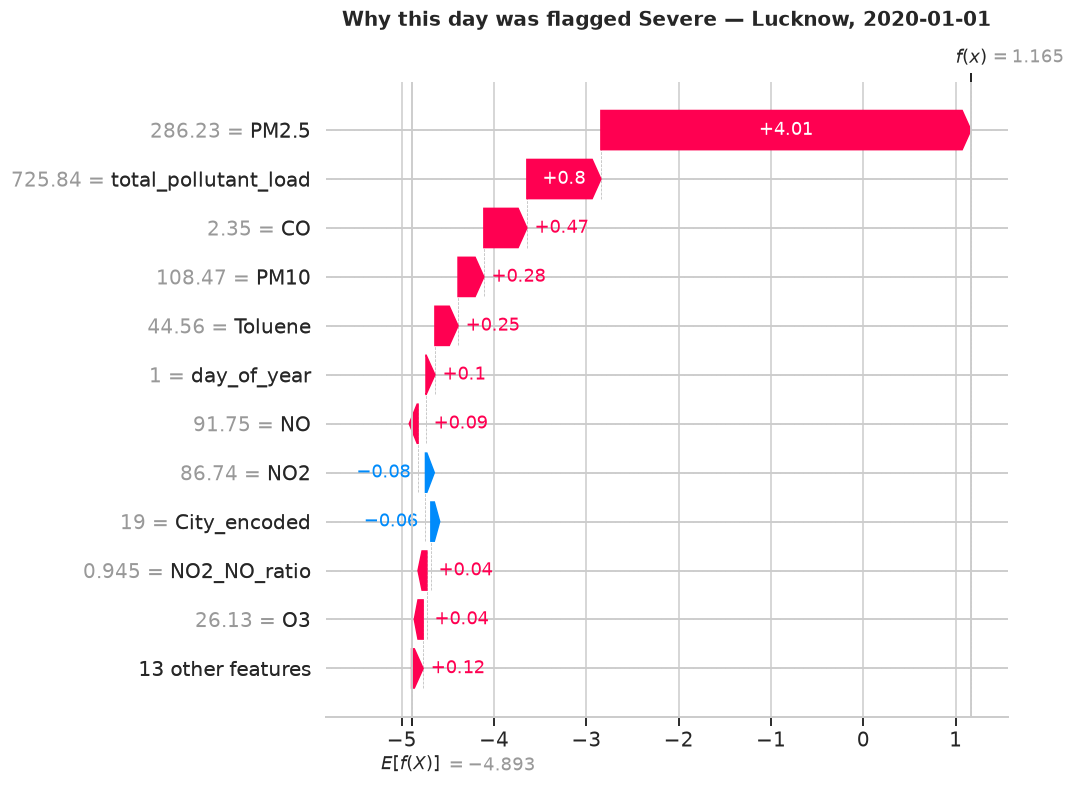

In [28]:
# --- Figure 14: local explanation for one high-risk day ----------------------------
severe_idx = np.where(predictions[BEST_MODEL_NAME] == SEVERE)[0]
if len(severe_idx) == 0:
    severe_idx = np.where(y_test.values == SEVERE)[0]
i = int(severe_idx[0])

row_meta = df.loc[X_test_imp.index[i], ['City', 'Date', 'AQI', 'AQI_Bucket']]
print(f"Explaining a single prediction")
print(f"  City      : {row_meta['City']}")
print(f"  Date      : {row_meta['Date'].date()}")
print(f"  True AQI  : {row_meta['AQI']:.0f}  ({row_meta['AQI_Bucket']})")
print(f"  Predicted : {BUCKET_ORDER[predictions[BEST_MODEL_NAME][i]]}")

base_val = explainer.expected_value[SEVERE] if np.ndim(explainer.expected_value) else explainer.expected_value
exp = shap.Explanation(
    values=class_shap(shap_values, SEVERE)[i],
    base_values=base_val,
    data=X_test_imp.iloc[i].values,
    feature_names=list(X_test_imp.columns),
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title(f"Why this day was flagged Severe — {row_meta['City']}, {row_meta['Date'].date()}",
          fontweight='bold', pad=15)
plt.savefig('figures/shap_14_local_waterfall.png', bbox_inches='tight')
plt.show()

**Reading a single decision.** The waterfall starts at the model's base rate — its prior belief that any
random city-day is Severe, which is low — and shows each feature pushing that estimate up (red) or down
(blue) until it reaches the final prediction for this specific day.

This is the artefact that makes the system deployable. The output is no longer "the model says Severe"; it
is "the model says Severe **because** PM2.5 was extreme, the total load was high, and it was mid-winter."
A municipal officer can check each of those against their own dashboard in ten seconds and decide whether
they agree. That is human oversight in practice rather than in principle.

LIVE DEMO — Delhi, 15 Nov 2020 (synthetic post-Diwali reading)
  Predicted AQI band : Severe
  Confidence         : 96.5%



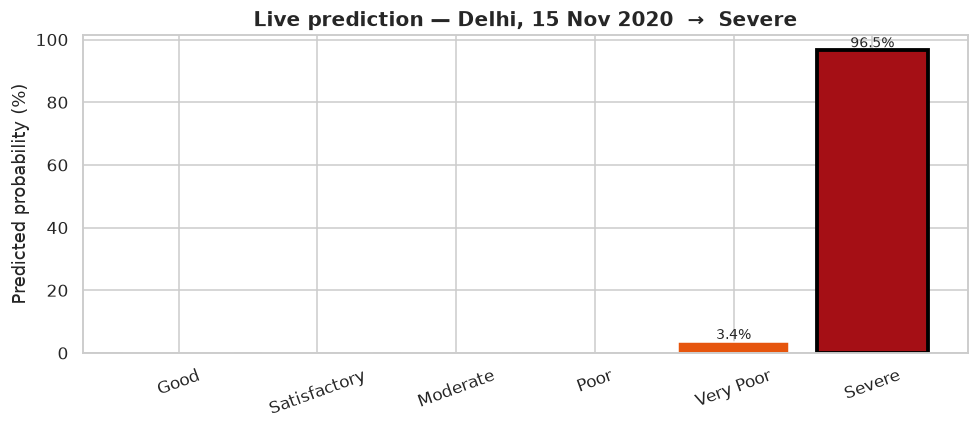

In [29]:
# --- Live demo: prediction on one realistic synthetic record -----------------------
def predict_aqi(city, date, readings, model=None):
    '''Score a single city-day through the exact training pipeline. Used for the demo video.'''
    model = model or best_model
    row = pd.DataFrame([readings])
    d = pd.Timestamp(date)

    row['month'] = d.month
    row['day_of_week'] = d.dayofweek
    row['day_of_year'] = d.dayofyear
    row['is_winter'] = int(d.month in (10, 11, 12, 1, 2))
    row['month_sin'] = np.sin(2 * np.pi * d.month / 12)
    row['month_cos'] = np.cos(2 * np.pi * d.month / 12)
    row['PM2.5_PM10_ratio'] = row.get('PM2.5', 0) / (row.get('PM10', 0) + 1e-6)
    row['NO2_NO_ratio'] = row.get('NO2', 0) / (row.get('NO', 0) + 1e-6)
    row['total_pollutant_load'] = sum(readings.get(c, 0) for c in pollutant_cols)
    row['City_encoded'] = le_city.transform([city])[0]

    season = get_season(d.month)
    for s in ['Post-Monsoon', 'Summer', 'Winter']:
        col = f'season_{s}'
        if col in features:
            row[col] = (season == s)

    row = row.reindex(columns=features)
    row = pd.DataFrame(imputer.transform(row), columns=features)

    proba = model.predict_proba(row)[0]
    pred = int(np.argmax(proba))
    return BUCKET_ORDER[pred], proba

# A plausible Delhi winter morning after Diwali
demo_reading = {'PM2.5': 310.0, 'PM10': 480.0, 'NO': 55.0, 'NO2': 95.0, 'NOx': 120.0,
                'NH3': 45.0, 'CO': 3.8, 'SO2': 22.0, 'O3': 35.0,
                'Benzene': 8.0, 'Toluene': 15.0}

label, proba = predict_aqi('Delhi', '2020-11-15', demo_reading)
print(f"LIVE DEMO — Delhi, 15 Nov 2020 (synthetic post-Diwali reading)")
print(f"  Predicted AQI band : {label}")
print(f"  Confidence         : {proba.max():.1%}\n")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(BUCKET_ORDER, proba * 100, color=BUCKET_COLORS, edgecolor='white')
bars[int(np.argmax(proba))].set_edgecolor('black')
bars[int(np.argmax(proba))].set_linewidth(2.5)
ax.set_ylabel('Predicted probability (%)')
ax.set_title(f'Live prediction — Delhi, 15 Nov 2020  →  {label}')
for b, p in zip(bars, proba * 100):
    if p > 0.8:
        ax.text(b.get_x() + b.get_width()/2, p + 1, f'{p:.1f}%', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('figures/demo_15_live_prediction.png')
plt.show()

**On uncertainty.** Notice the model does not return a bare label — it returns a probability across all six
bands, and that distribution is itself operationally useful. A 95% Severe prediction and a 45% Severe
prediction should not trigger the same municipal response. Our recommendation for deployment is a two-tier
policy: high-confidence severe predictions trigger automatic advisories, while low-confidence ones are
routed to a human duty officer for review. A model that says "probably bad, but I am not sure" is far more
trustworthy than one that always sounds certain.

### Ethics Statement

**Geographic and sampling bias.** The CPCB network is overwhelmingly urban and concentrated in larger
cities, which Figure 3 makes plain. Rural India, where biomass cooking fuel is a major exposure route, is
effectively invisible to this model. Deploying it as a *national* system would quietly extend protection to
the already-monitored and leave everyone else out — the classic pattern where a well-intentioned model
reproduces existing infrastructure inequality. It should be presented as a city-level tool for the cities
it was trained on, and nothing more.

**Asymmetric error costs.** Our two error types are not remotely equivalent:

- A **false negative** — predicting "Moderate" on a genuinely Severe day — means no advisory is issued.
  Asthmatic children go to school, outdoor workers stay on site, and people are exposed to hazardous air
  with no warning. The cost is measured in hospital admissions.
- A **false positive** — predicting "Severe" on a merely Poor day — means an unnecessary construction halt
  or school closure. The cost is economic and political: real, but recoverable.

Because the costs are asymmetric, our optimisation is too. `class_weight='balanced'`, macro-F1 selection,
and our explicit tracking of Severe-class recall all deliberately trade some precision for recall on the
dangerous classes. We would rather cry wolf occasionally than miss a genuine emergency. That said,
false positives are not free either — an authority that over-triggers GRAP will find the public stops
complying, which destroys the value of every future alert. This trade-off should be periodically
re-calibrated with the health department rather than fixed permanently at our chosen threshold.

**Privacy.** The dataset carries no personally identifiable information. Every record is a station-level
daily aggregate for a city, so there is no individual to re-identify and no consent issue in the training
data. This is one of the cleaner social-good ML problems in that respect, and we should keep it that way:
if the system is later extended with mobile-phone-derived exposure or location data, the privacy analysis
becomes an entirely new question that this notebook does not answer.

**Uncertainty and human oversight.** The model outputs calibrated probabilities, not verdicts. We recommend
that it is deployed as a *decision-support* tool inside an existing GRAP workflow, with a named human
officer accountable for every activation. The SHAP local explanation in Figure 14 exists precisely so that
officer can audit the reasoning rather than defer to it.

**Temporal validity and deployment limits.** The model was validated against a 2020 test year that included
the COVID lockdown — an extreme distribution shift. It should be retrained at least annually, monitored for
feature drift, and re-checked after any major policy change (new emission norms, fleet electrification, a
change in stubble-burning enforcement). Finally, the honest scope limit: this is a *nowcasting* model. It
classifies today's air from today's sensor readings. It is not a forecast, and it must not be presented as
one to the public — genuine multi-day forecasting requires meteorological inputs (wind speed, boundary
layer height, precipitation) that this dataset does not contain.

---
## Summary

<!--OBSERVATION_SUMMARY-->